# 语言指令驱动的桌面机器人

**组名：第十三组**  
**项目名称：基于规则解析的语言指令驱动桌面机器人仿真系统**

## 项目目标

用户输入中文多步骤指令，系统依次完成：

1. 识别颜色、动作、目标区域和执行顺序；
2. 转换为结构化任务列表；
3. 调用机器人技能执行；
4. 检查任务是否成功，必要时重试；
5. 输出执行日志、统计表和动画。

本项目不训练大语言模型，而是使用**关键词匹配与规则解析**。机器人采用稳定的运动学简化推杆，重点展示“语言—规划—动作—反馈”的具身智能闭环。

## 0. 环境准备

推荐使用 Google Colab 或 Jupyter Notebook。首次运行若缺少依赖，下面的单元格会自动安装。  
生成 GIF 时使用 PyBullet 的离屏渲染，不需要真实机器人或独立显卡。

In [13]:
import importlib.util, subprocess, sys

for package, import_name in [
    ("pybullet", "pybullet"),
    ("imageio", "imageio"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
]:
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("环境准备完成")

环境准备完成


In [14]:
import re
import time
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pybullet as p
import pybullet_data
from IPython.display import Image, display

np.set_printoptions(precision=3, suppress=True)
OUTPUT_DIR = Path("topic3_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
print("库导入完成")

库导入完成


## 1. 中文规则解析器

解析器支持：

- 颜色：红色、绿色、蓝色；
- 动作：推动、移动、放到、返回；
- 区域：左边、右边、中间、起点；
- 同义表达：“左侧/左边”“回到/返回”等；
- 多步骤连接词：“先、再、然后、最后”；
- 错误检测：未知颜色、未知区域、缺失动作等。

In [15]:
COLOR_NAME_TO_KEY = {
    "红色": "red", "绿色": "green", "蓝色": "blue",
    "黄色": "yellow", "紫色": "purple", "橙色": "orange",
    "粉色": "pink", "黑色": "black", "白色": "white",
    "灰色": "gray", "棕色": "brown", "青色": "cyan",
}
SHORT_COLOR_NAMES = {
    "红": "红色", "绿": "绿色", "蓝": "蓝色",
    "黄": "黄色", "紫": "紫色", "橙": "橙色",
    "粉": "粉色", "黑": "黑色", "白": "白色",
    "灰": "灰色", "棕": "棕色", "青": "青色",
}
# 当前桌面开始时实际存在的方块。
SCENE_COLOR_KEYS = {"red", "green", "blue"}
TARGET_WORDS = {
    "left": ["左边", "左侧", "左区"],
    "middle": ["中间", "中央", "中部"],
    "right": ["右边", "右侧", "右区"],
}
ACTION_WORDS = {
    "push": ["推动", "推到", "推向", "推"],
    "move": ["移动", "移到", "放到", "送到"],
}
RETURN_WORDS = ["回到起点", "返回起点", "回起点", "复位"]

COLOR_CN = {"red": "红色", "green": "绿色", "blue": "蓝色"}
TARGET_CN = {"left": "左边", "middle": "中间", "right": "右边"}


def find_key(text, vocabulary):
    for key, words in vocabulary.items():
        if any(word in text for word in words):
            return key
    return None


def extract_color(text):
    # 返回(内部颜色键, 中文颜色名)，也能提取未预先登记的“某某色”表达。
    for chinese_name, key in COLOR_NAME_TO_KEY.items():
        if chinese_name in text:
            return key, chinese_name

    for short_name, full_name in SHORT_COLOR_NAMES.items():
        if short_name + "方块" in text or short_name + "物体" in text:
            return COLOR_NAME_TO_KEY[full_name], full_name

    match = re.search(r"([\u4e00-\u9fa5]{1,3}色)", text)
    if match:
        chinese_name = match.group(1)
        return COLOR_NAME_TO_KEY.get(chinese_name), chinese_name

    return None, None


def split_command(command):
    cleaned = re.sub(r"[，。；;！!]", "，", command.strip())
    cleaned = re.sub(r"(首先|先|接着|随后|然后|最后|再)", "，", cleaned)
    return [part.strip() for part in cleaned.split("，") if part.strip()]


def parse_command(command):
    # 把中文命令解析为任务列表；错误时返回清楚的原因。
    tasks, errors = [], []
    for index, clause in enumerate(split_command(command), start=1):
        if any(word in clause for word in RETURN_WORDS):
            tasks.append({"action": "return_home"})
            continue

        color, color_cn = extract_color(clause)
        target = find_key(clause, TARGET_WORDS)
        action = find_key(clause, ACTION_WORDS)

        if color_cn is None:
            errors.append(f"第{index}步没有识别到颜色：{clause}")
        elif color not in SCENE_COLOR_KEYS:
            errors.append(
                f"第{index}步已识别颜色“{color_cn}”，"
                f"但当前场景中不存在对应颜色的方块"
            )
        elif target is None and any(w in clause for w in ["上面", "下面", "前面", "后面"]):
            errors.append(f"第{index}步包含不支持的目标区域：{clause}")
        elif target is None:
            errors.append(f"第{index}步缺少可识别的目标区域：{clause}")
        elif action is None:
            errors.append(f"第{index}步缺少可识别的动作：{clause}")
        else:
            tasks.append({"action": action, "object_color": color, "target": target})

    return {"success": not errors and bool(tasks), "tasks": tasks, "errors": errors}

In [16]:
demo_commands = [
    "把红色方块推到左边",
    "先把蓝色方块推到右边，然后回到起点",
    "把绿色方块移动到中央，再把红色方块放到左侧",
    "把紫色方块推到上面",
]

for command in demo_commands:
    print("\n输入：", command)
    print("解析：", parse_command(command))


输入： 把红色方块推到左边
解析： {'success': True, 'tasks': [{'action': 'push', 'object_color': 'red', 'target': 'left'}], 'errors': []}

输入： 先把蓝色方块推到右边，然后回到起点
解析： {'success': True, 'tasks': [{'action': 'push', 'object_color': 'blue', 'target': 'right'}, {'action': 'return_home'}], 'errors': []}

输入： 把绿色方块移动到中央，再把红色方块放到左侧
解析： {'success': True, 'tasks': [{'action': 'move', 'object_color': 'green', 'target': 'middle'}, {'action': 'move', 'object_color': 'red', 'target': 'left'}], 'errors': []}

输入： 把紫色方块推到上面
解析： {'success': False, 'tasks': [], 'errors': ['第1步已识别颜色“紫色”，但当前场景中不存在对应颜色的方块']}


## 2. 搭建 PyBullet 桌面环境

场景包含桌面、三个彩色方块、左中右三个目标区和一个简化推杆机器人。  
为保证课堂演示稳定，推杆运动由程序规划，方块位置由运动学轨迹同步更新。

In [17]:
try:
    p.disconnect()
except Exception:
    pass

physics_id = p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)

PLANE_Z = 0.0
BLOCK_Z = 0.055
HOME = np.array([0.0, -0.55, 0.075])
INITIAL_POSITIONS = {
    "red": np.array([-0.32, -0.16, BLOCK_Z]),
    "green": np.array([0.00, -0.16, BLOCK_Z]),
    "blue": np.array([0.32, -0.16, BLOCK_Z]),
}
SCENE_LAYOUTS = {
    "standard": {
        "red": [-0.32, -0.16, BLOCK_Z],
        "green": [0.00, -0.16, BLOCK_Z],
        "blue": [0.32, -0.16, BLOCK_Z],
    },
    "swapped": {
        "red": [0.34, -0.22, BLOCK_Z],
        "green": [0.00, -0.05, BLOCK_Z],
        "blue": [-0.34, -0.22, BLOCK_Z],
    },
    "diagonal": {
        "red": [-0.38, -0.34, BLOCK_Z],
        "green": [0.00, -0.12, BLOCK_Z],
        "blue": [0.38, 0.10, BLOCK_Z],
    },
}
TARGET_POSITIONS = {
    "left": np.array([-0.48, 0.43, BLOCK_Z]),
    "middle": np.array([0.00, 0.43, BLOCK_Z]),
    "right": np.array([0.48, 0.43, BLOCK_Z]),
}
RGBA = {
    "red": [0.90, 0.12, 0.12, 1],
    "green": [0.10, 0.72, 0.25, 1],
    "blue": [0.10, 0.34, 0.92, 1],
}


def make_box(position, half_extents, color, mass=0):
    collision = p.createCollisionShape(p.GEOM_BOX, halfExtents=half_extents)
    visual = p.createVisualShape(p.GEOM_BOX, halfExtents=half_extents, rgbaColor=color)
    return p.createMultiBody(
        baseMass=mass,
        baseCollisionShapeIndex=collision,
        baseVisualShapeIndex=visual,
        basePosition=position,
    )


def build_scene(scenario="standard", seed=42):
    # 建立指定场景；random场景使用种子保证实验可重复。
    p.resetSimulation()
    p.setGravity(0, 0, -9.81)
    make_box([0, 0, -0.035], [0.72, 0.72, 0.035], [0.82, 0.82, 0.84, 1])

    # 半透明目标区
    zone_colors = {
        "left": [1.0, 0.70, 0.70, 0.55],
        "middle": [0.70, 1.0, 0.75, 0.55],
        "right": [0.70, 0.82, 1.0, 0.55],
    }
    global zone_ids, block_ids, robot_id
    zone_ids = {
        name: make_box(pos + [0, 0, -0.047], [0.15, 0.13, 0.008], zone_colors[name])
        for name, pos in TARGET_POSITIONS.items()
    }
    if scenario == "random":
        rng = np.random.default_rng(seed)
        layout = {}
        used = []
        for color in ["red", "green", "blue"]:
            for _ in range(100):
                candidate = np.array([
                    rng.uniform(-0.48, 0.48),
                    rng.uniform(-0.42, 0.05),
                    BLOCK_Z,
                ])
                if all(np.linalg.norm(candidate[:2] - old[:2]) > 0.18 for old in used):
                    layout[color] = candidate
                    used.append(candidate)
                    break
    elif scenario in SCENE_LAYOUTS:
        layout = {
            color: np.array(position, dtype=float)
            for color, position in SCENE_LAYOUTS[scenario].items()
        }
    else:
        raise ValueError(
            f"未知场景：{scenario}。可选 standard、swapped、diagonal、random"
        )

    block_ids = {
        color: make_box(pos, [0.055, 0.055, 0.055], RGBA[color])
        for color, pos in layout.items()
    }
    robot_id = make_box(HOME, [0.045, 0.075, 0.075], [0.22, 0.22, 0.25, 1])
    p.performCollisionDetection()
    return get_state()


def get_position(body_id):
    return np.array(p.getBasePositionAndOrientation(body_id)[0])


def get_state():
    return {
        "robot": get_position(robot_id),
        "blocks": {color: get_position(body) for color, body in block_ids.items()},
    }


build_scene("standard")
print("场景建立完成：3个方块、3个目标区、1个简化机器人")

场景建立完成：3个方块、3个目标区、1个简化机器人


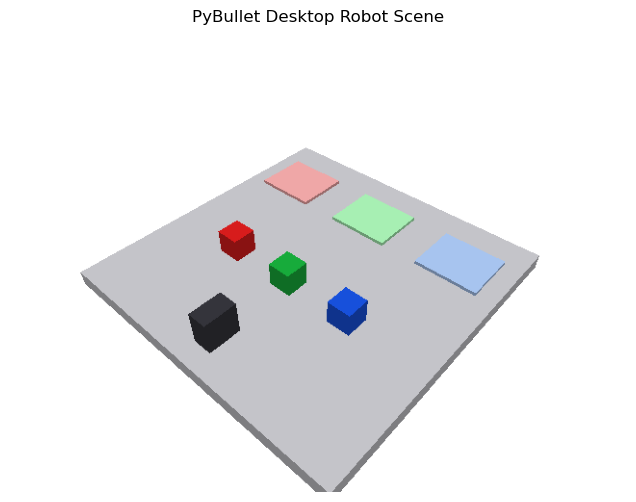

In [18]:
VIEW = p.computeViewMatrix(
    cameraEyePosition=[1.15, -1.25, 1.55],
    cameraTargetPosition=[0, 0.03, 0],
    cameraUpVector=[0, 0, 1],
)
PROJ = p.computeProjectionMatrixFOV(fov=48, aspect=4/3, nearVal=0.1, farVal=5)


def capture_frame(width=640, height=480):
    image = p.getCameraImage(
        width, height, VIEW, PROJ,
        renderer=p.ER_TINY_RENDERER,
    )
    return np.asarray(image[2], dtype=np.uint8).reshape(height, width, 4)[..., :3]


plt.figure(figsize=(8, 6))
plt.imshow(capture_frame())
plt.axis("off")
plt.title("PyBullet Desktop Robot Scene")
plt.show()

## 2.1 多场景对比

项目提供四种场景：

- `standard`：标准横向排列；
- `swapped`：红蓝位置交换；
- `diagonal`：三个方块沿对角线分布；
- `random`：使用随机种子生成可重复的随机位置。

不同场景可以证明机器人不是只记住一套固定画面。调用示例：`build_scene("random", seed=7)`。

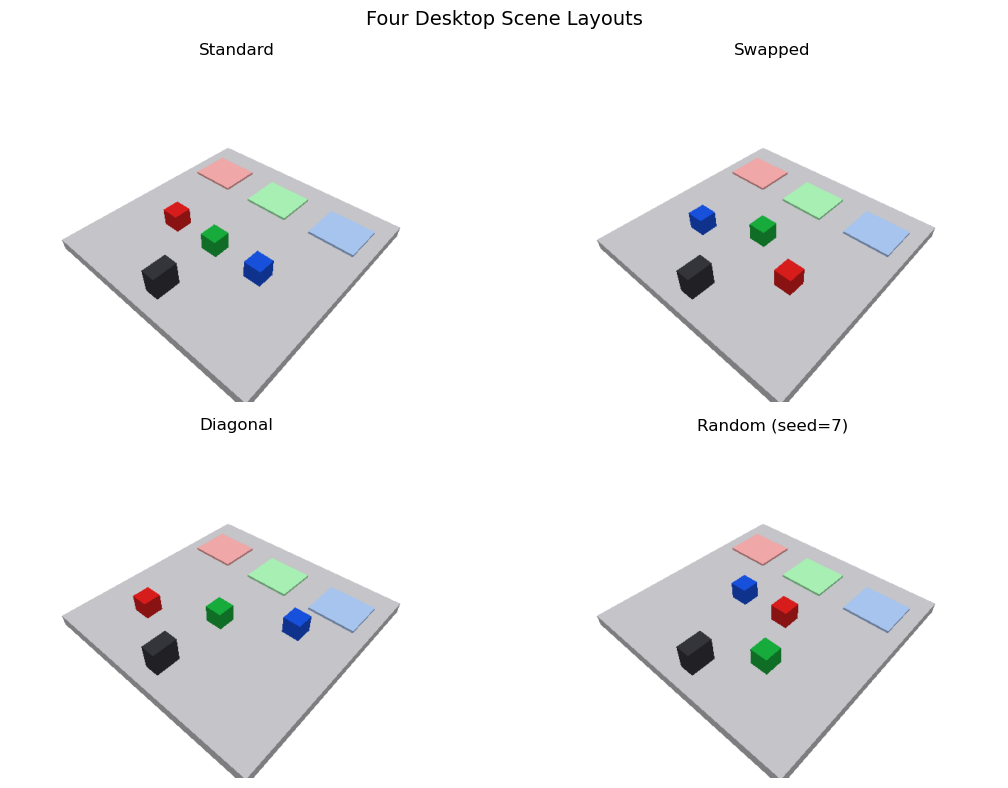

场景对比图已保存： topic3_outputs\scene_comparison.png


{'robot': array([ 0.   , -0.55 ,  0.075]),
 'blocks': {'red': array([-0.32 , -0.16 ,  0.055]),
  'green': array([ 0.   , -0.16 ,  0.055]),
  'blue': array([ 0.32 , -0.16 ,  0.055])}}

In [19]:
scene_names = ["standard", "swapped", "diagonal", "random"]
scene_titles = ["Standard", "Swapped", "Diagonal", "Random (seed=7)"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, scene_name, title in zip(axes.ravel(), scene_names, scene_titles):
    if scene_name == "random":
        build_scene(scene_name, seed=7)
    else:
        build_scene(scene_name)
    ax.imshow(capture_frame())
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Four Desktop Scene Layouts", fontsize=14)
plt.tight_layout()
scene_comparison_path = OUTPUT_DIR / "scene_comparison.png"
plt.savefig(scene_comparison_path, dpi=160, bbox_inches="tight")
plt.show()
print("场景对比图已保存：", scene_comparison_path)

# 恢复标准场景，供后续单元格继续使用。
build_scene("standard")

## 3. 机器人技能库

每个技能只完成一个明确动作：

- `find_object(color)`：读取方块位置；
- `move_to_object(color)`：移动到方块后方；
- `push_object_to_area(color, target)`：沿规划轨迹推动；
- `check_success(color, target)`：检查是否进入目标区；
- `return_home()`：返回起点；
- `retry_skill(...)`：首次失败时重试。

In [20]:
FRAMES = []


def interpolate(start, end, steps=24):
    start, end = np.asarray(start), np.asarray(end)
    return [(1-t)*start + t*end for t in np.linspace(0, 1, steps)]


def record_frame():
    FRAMES.append(capture_frame())


def find_object(color):
    if color not in block_ids:
        return None
    return get_position(block_ids[color])


def move_robot(position, steps=18, record=True):
    start = get_position(robot_id)
    for point in interpolate(start, position, steps):
        p.resetBasePositionAndOrientation(robot_id, point, [0, 0, 0, 1])
        p.stepSimulation()
        if record:
            record_frame()


def move_to_object(color, record=True):
    object_pos = find_object(color)
    if object_pos is None:
        return False
    approach = object_pos + np.array([0, -0.12, 0.02])
    move_robot(approach, record=record)
    return True


def push_object_to_area(color, target, record=True, inject_failure=False):
    if color not in block_ids or target not in TARGET_POSITIONS:
        return False
    start = find_object(color)
    goal = TARGET_POSITIONS[target].copy()
    # 用于演示重试机制：第一次故意少走一段。
    if inject_failure:
        goal = start + 0.55 * (goal - start)

    robot_start = get_position(robot_id)
    robot_goal = goal + np.array([0, -0.12, 0.02])
    block_path = interpolate(start, goal, 28)
    robot_path = interpolate(robot_start, robot_goal, 28)
    for block_point, robot_point in zip(block_path, robot_path):
        p.resetBasePositionAndOrientation(block_ids[color], block_point, [0, 0, 0, 1])
        p.resetBasePositionAndOrientation(robot_id, robot_point, [0, 0, 0, 1])
        p.stepSimulation()
        if record:
            record_frame()
    return True


def check_success(color, target, tolerance=0.13):
    actual = find_object(color)[:2]
    desired = TARGET_POSITIONS[target][:2]
    return float(np.linalg.norm(actual - desired)) <= tolerance


def return_home(record=True):
    move_robot(HOME, steps=22, record=record)
    return True


def retry_skill(color, target, record=True):
    move_to_object(color, record=record)
    push_object_to_area(color, target, record=record, inject_failure=False)
    return check_success(color, target)

## 4. 状态机与任务执行

状态流程：

`WAIT_FOR_COMMAND → PARSE_COMMAND → BUILD_TASK_LIST → EXECUTE_TASK → CHECK_TASK_SUCCESS → RETRY_OR_ABORT → FINISH`

执行状态:
WAIT_FOR_COMMAND
PARSE_COMMAND
BUILD_TASK_LIST
EXECUTE_TASK
CHECK_TASK_SUCCESS
FINISH


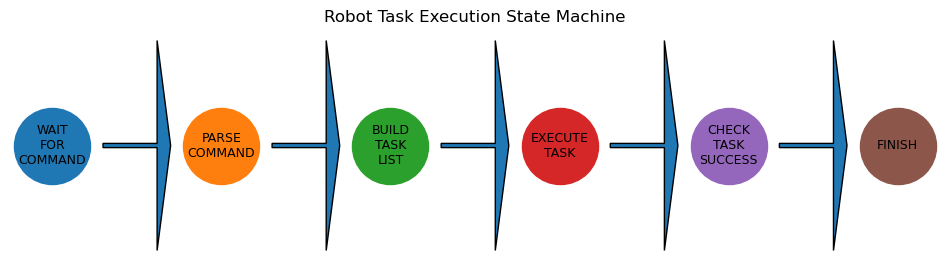

In [26]:
import matplotlib.pyplot as plt


# ==========================
# 机器人任务状态机
# ==========================

def robot_state_machine(command):

    states = []

    # 1. 等待指令
    state = "WAIT_FOR_COMMAND"
    states.append(state)


    # 2. 解析指令
    state = "PARSE_COMMAND"
    states.append(state)


    # 模拟解析结果
    parse_success = True


    if parse_success:

        # 3. 建立任务列表
        state = "BUILD_TASK_LIST"
        states.append(state)


        # 4. 执行任务
        state = "EXECUTE_TASK"
        states.append(state)


        # 5. 检查任务
        state = "CHECK_TASK_SUCCESS"
        states.append(state)


        task_success = True


        if task_success:

            state = "FINISH"
            states.append(state)

        else:

            state = "RETRY_OR_ABORT"
            states.append(state)


    else:

        state = "RETRY_OR_ABORT"
        states.append(state)


    return states



# 执行状态机

result_states = robot_state_machine(
    "移动红色方块"
)


print("执行状态:")
for s in result_states:
    print(s)


# 状态机可视化
# ==========================


def visualize_states(states):

    plt.figure(figsize=(12,3))


    for i,state in enumerate(states):

        # 画节点
        plt.scatter(
            i,
            0,
            s=3000
        )


        plt.text(
            i,
            0,
            state.replace("_","\n"),
            ha="center",
            va="center",
            fontsize=9
        )


        # 画箭头
        if i < len(states)-1:

            plt.arrow(
                i+0.3,
                0,
                0.4,
                0,
                head_width=0.05,
                head_length=0.08,
                length_includes_head=True
            )


    plt.title(
        "Robot Task Execution State Machine"
    )


    plt.axis("off")

    plt.show()



# 输出图像

visualize_states(result_states)

In [ ]:
def execute_command(command, record=True, demonstrate_retry=False):
    parsed = parse_command(command)
    logs = []
    if not parsed["success"]:
        return {
            "command": command,
            "parse_success": False,
            "task_success": False,
            "errors": parsed["errors"],
            "tasks": parsed["tasks"],
            "logs": logs,
            "elapsed": 0.0,
        }

    start_time = time.perf_counter()
    all_success = True

    for task_no, task in enumerate(parsed["tasks"], start=1):
        action = task["action"]
        if action == "return_home":
            success = return_home(record=record)
            logs.append({
                "任务编号": task_no, "动作": "返回起点", "目标物体": "-",
                "目标区域": "起点", "执行结果": "成功" if success else "失败",
                "是否重试": "否", "失败原因": "",
            })
            all_success &= success
            continue

        color, target = task["object_color"], task["target"]
        move_to_object(color, record=record)
        inject = demonstrate_retry and task_no == 1
        push_object_to_area(color, target, record=record, inject_failure=inject)
        success = check_success(color, target)
        retried = False
        failure_reason = ""

        if not success:
            failure_reason = "首次推动距离不足"
            retried = True
            success = retry_skill(color, target, record=record)

        logs.append({
            "任务编号": task_no,
            "动作": "推动" if action == "push" else "移动",
            "目标物体": COLOR_CN[color] + "方块",
            "目标区域": TARGET_CN[target],
            "执行结果": "成功" if success else "失败",
            "是否重试": "是" if retried else "否",
            "失败原因": failure_reason,
        })
        all_success &= success

    elapsed = time.perf_counter() - start_time
    return {
        "command": command,
        "parse_success": True,
        "task_success": bool(all_success),
        "errors": [],
        "tasks": parsed["tasks"],
        "logs": logs,
        "elapsed": elapsed,
    }

## 5. 完整多步骤任务演示

下面故意让第一步少推动一段，系统检测失败后自动重试，以展示反馈闭环。

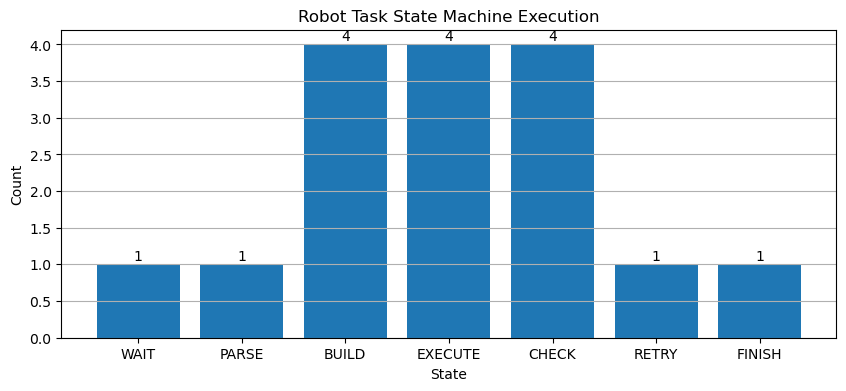

输入指令： 先把红色方块推到左边，再把蓝色方块移动到右侧，然后把绿色方块放到中央，最后回到起点
结构化任务：
  {'action': 'push', 'object_color': 'red', 'target': 'left'}
  {'action': 'move', 'object_color': 'blue', 'target': 'right'}
  {'action': 'move', 'object_color': 'green', 'target': 'middle'}
  {'action': 'return_home'}

总体执行结果： 成功


,任务编号,动作,目标物体,目标区域,执行结果,是否重试,失败原因
0,1,推动,红色方块,左边,成功,是,首次推动距离不足
1,2,移动,蓝色方块,右边,成功,否,
2,3,移动,绿色方块,中间,成功,否,
3,4,返回起点,-,起点,成功,否,


动画已保存： topic3_outputs\语言指令机器人演示.gif


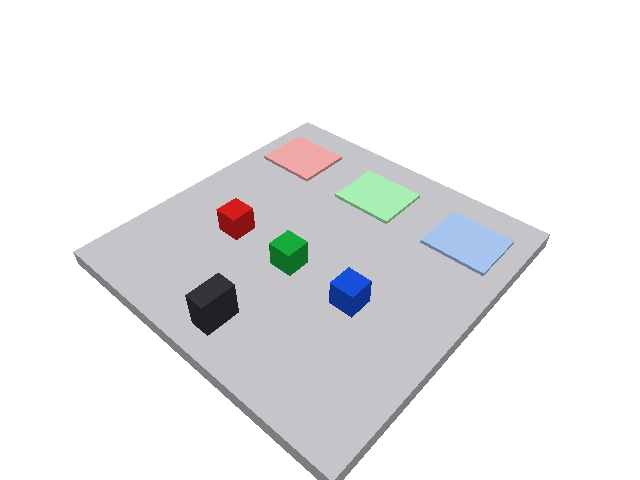

In [22]:
build_scene()
FRAMES.clear()
record_frame()

command = "先把红色方块推到左边，再把蓝色方块移动到右侧，然后把绿色方块放到中央，最后回到起点"
result = execute_command(command, record=True, demonstrate_retry=True)

print("输入指令：", result["command"])
print("结构化任务：")
for task in result["tasks"]:
    print(" ", task)
print("\n总体执行结果：", "成功" if result["task_success"] else "失败")

log_df = pd.DataFrame(result["logs"])
display(log_df)

gif_path = OUTPUT_DIR / "语言指令机器人演示.gif"
imageio.mimsave(gif_path, FRAMES, fps=15, loop=0)
print("动画已保存：", gif_path)
display(Image(filename=str(gif_path)))

## 6. 批量实验与量化评价

测试包括正常指令、同义表达、多步骤指令和错误指令。评价指标：

- 指令解析成功率；
- 合法指令的任务执行成功率；
- 平均执行时间；
- 平均重试次数。

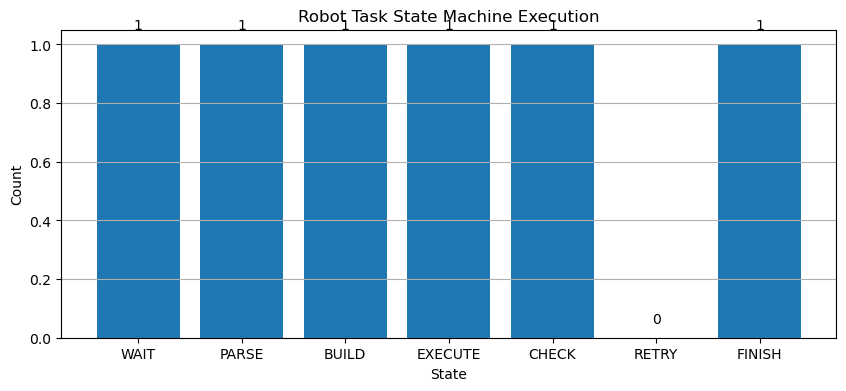

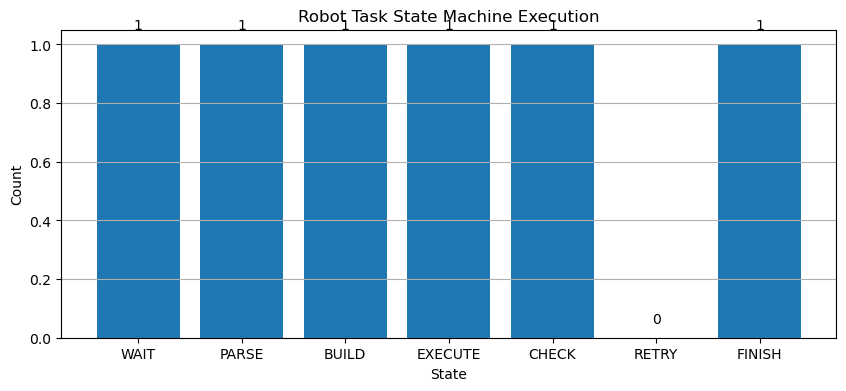

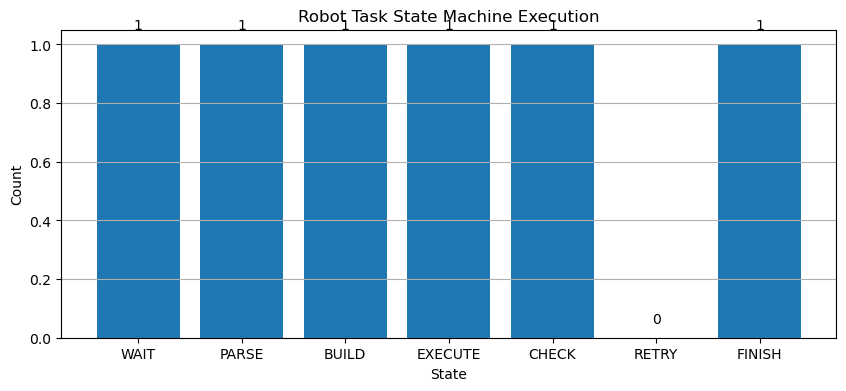

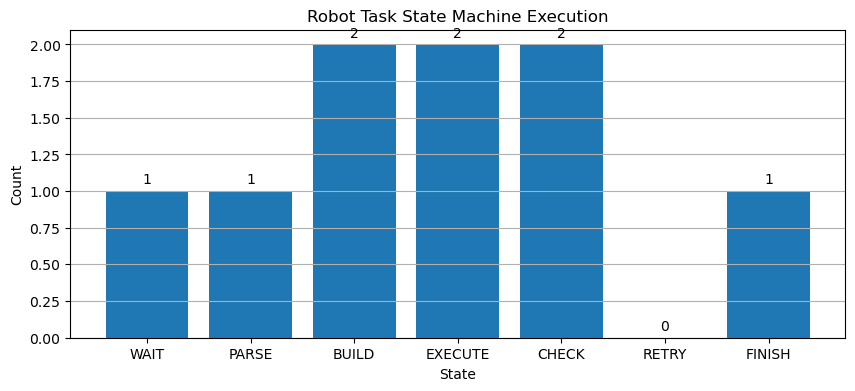

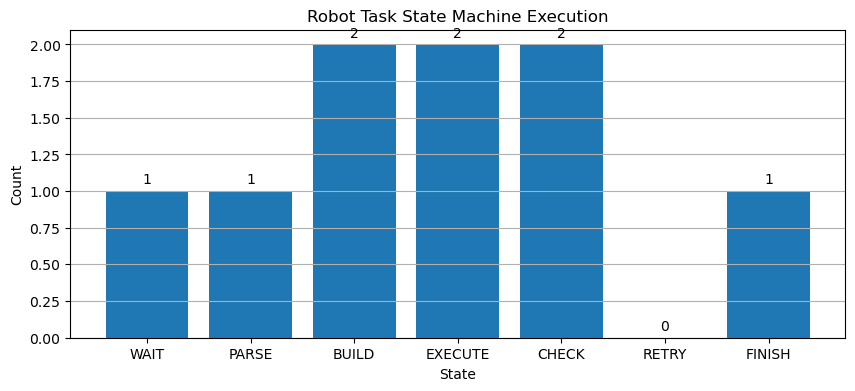

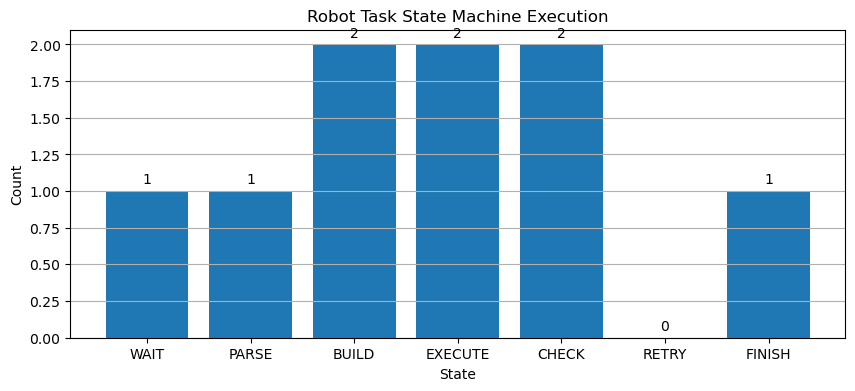

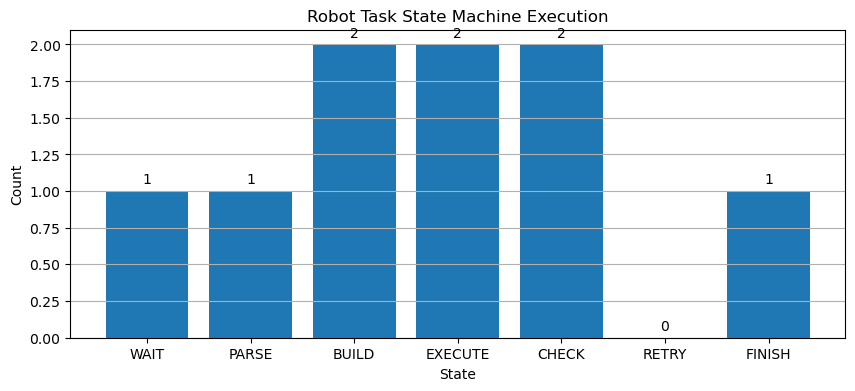

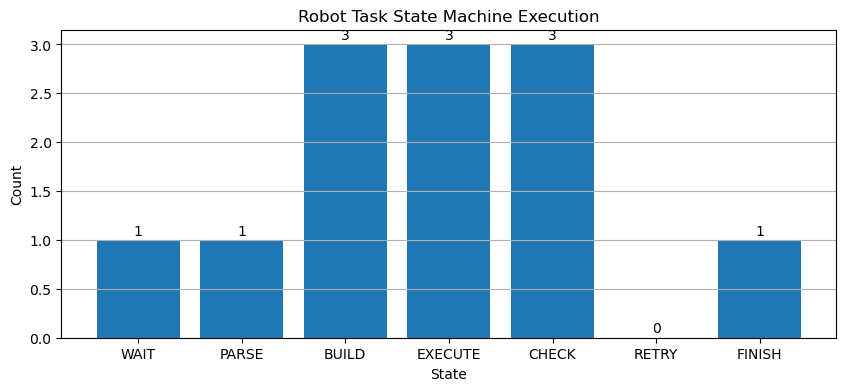

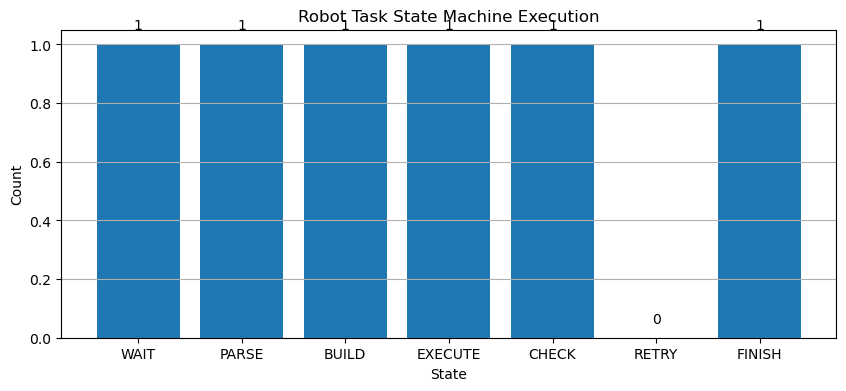

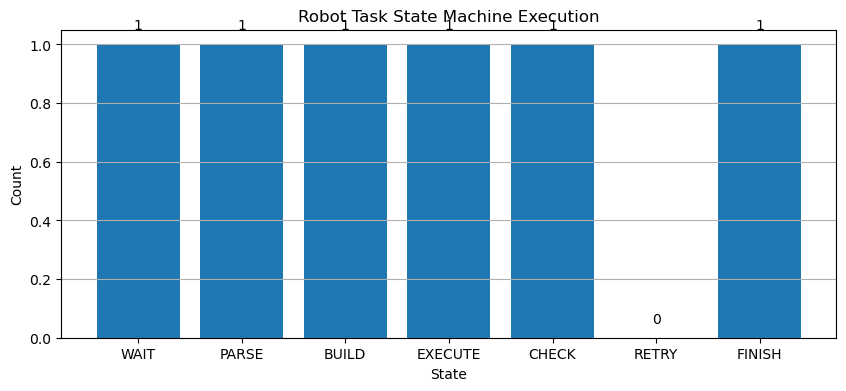

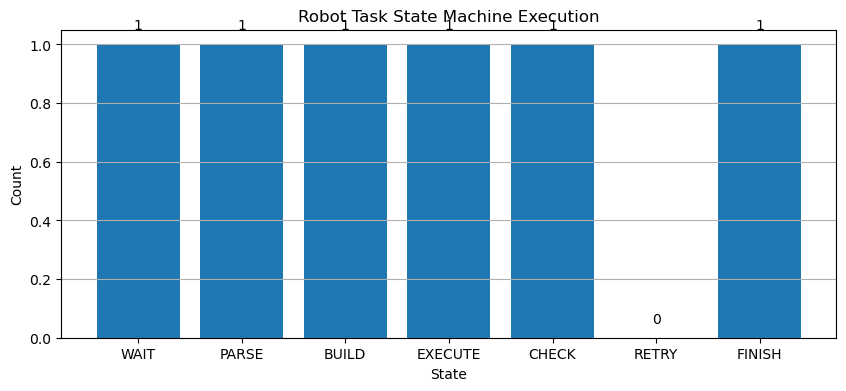

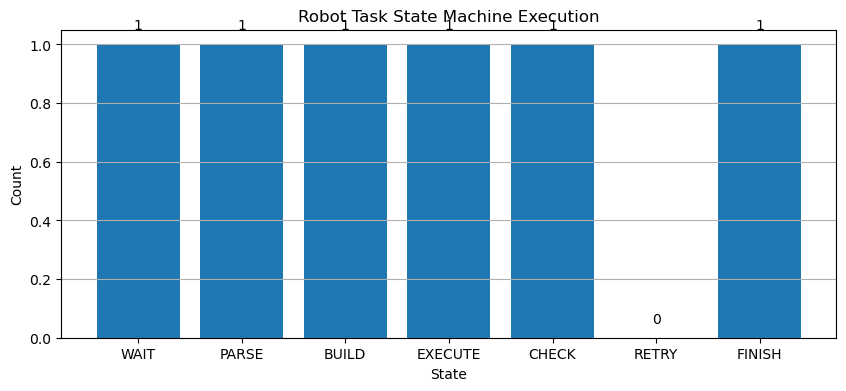

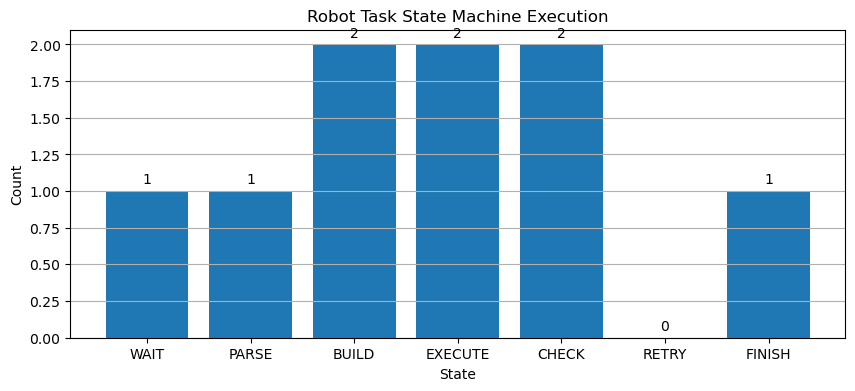

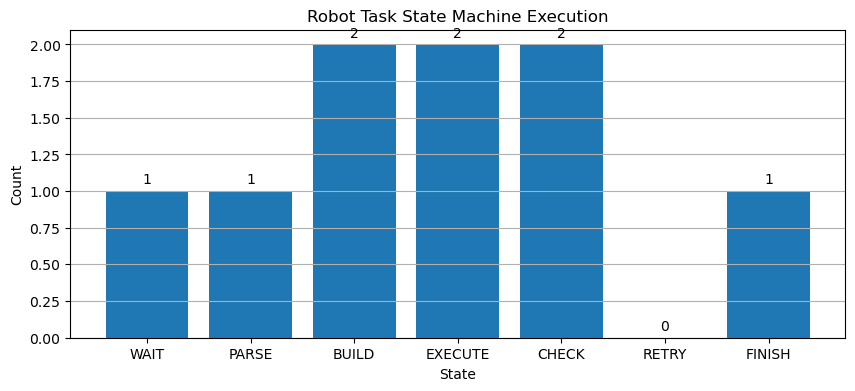

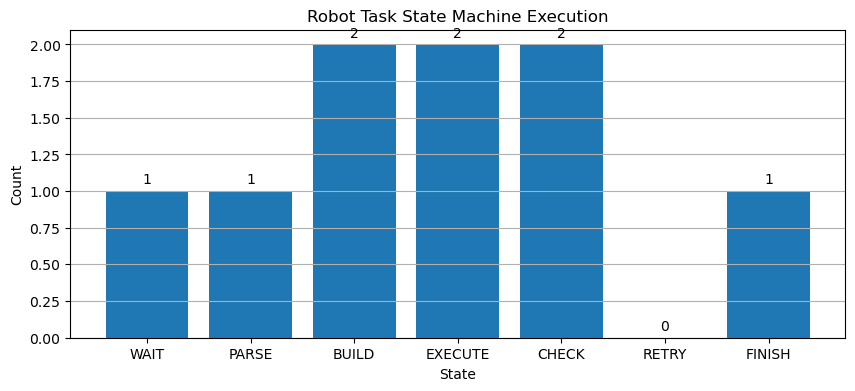

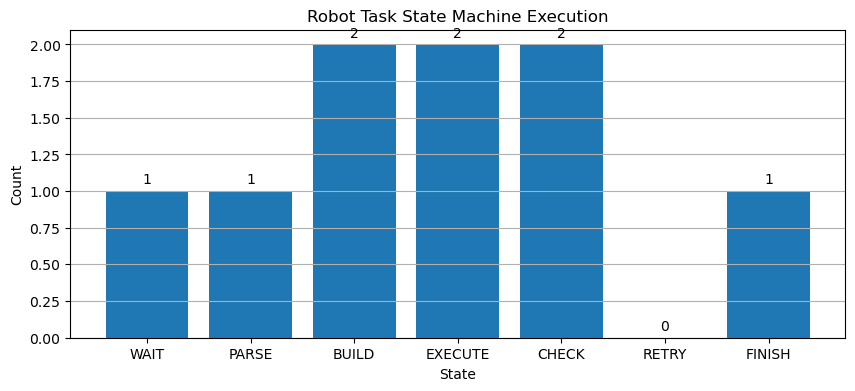

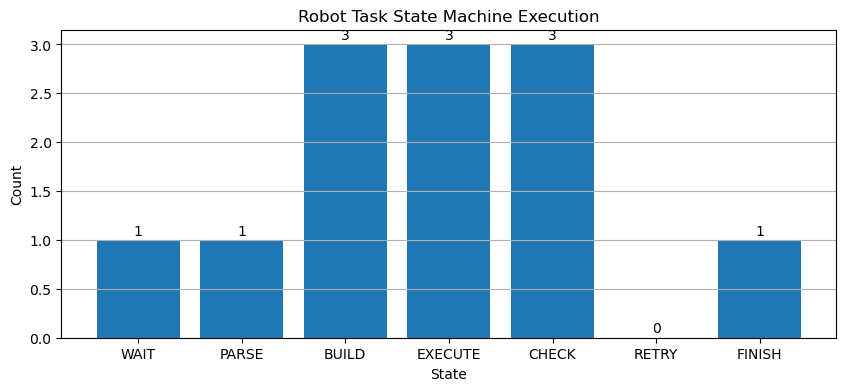

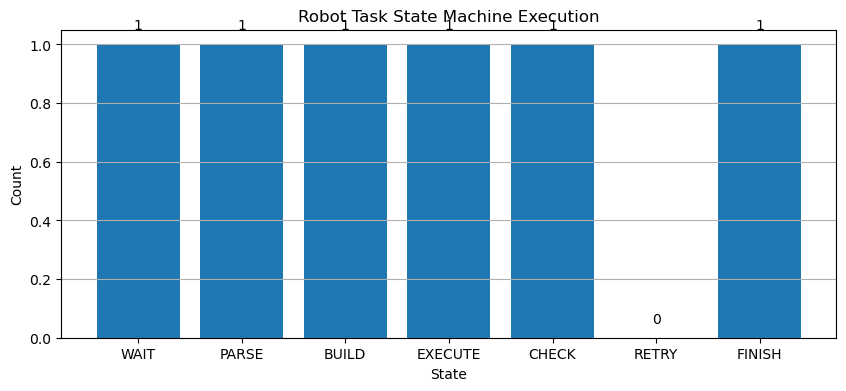

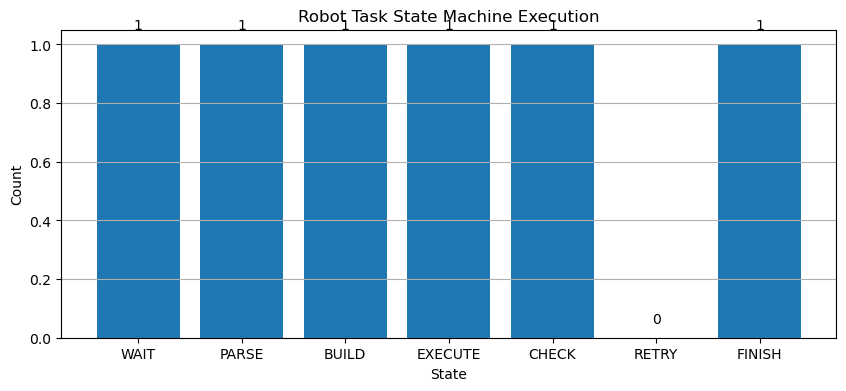

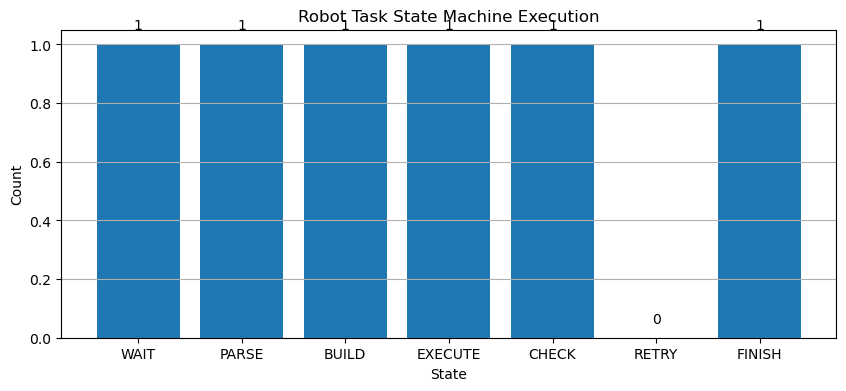

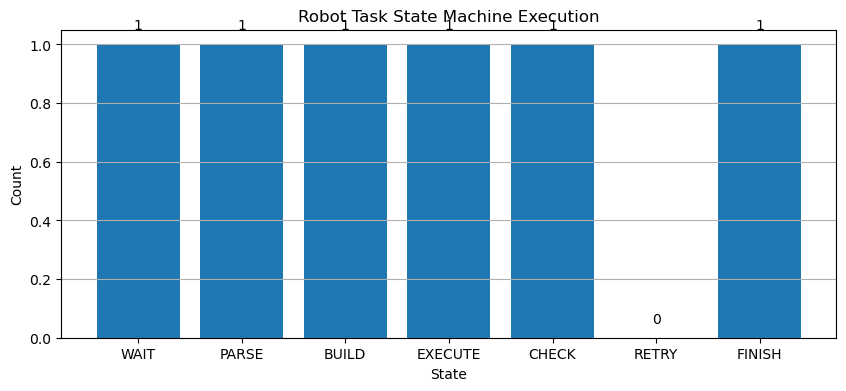

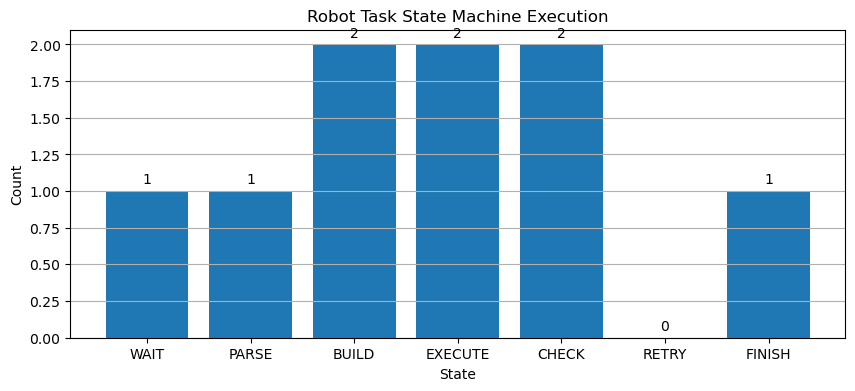

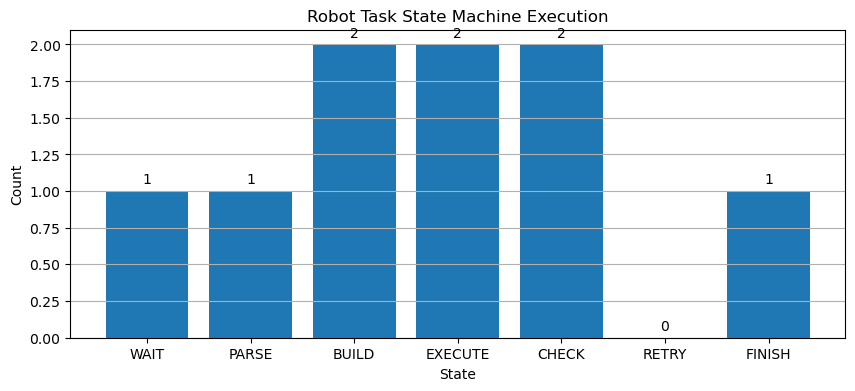

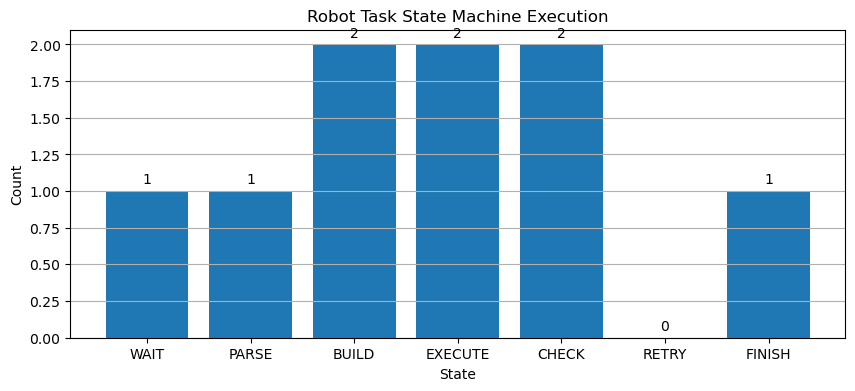

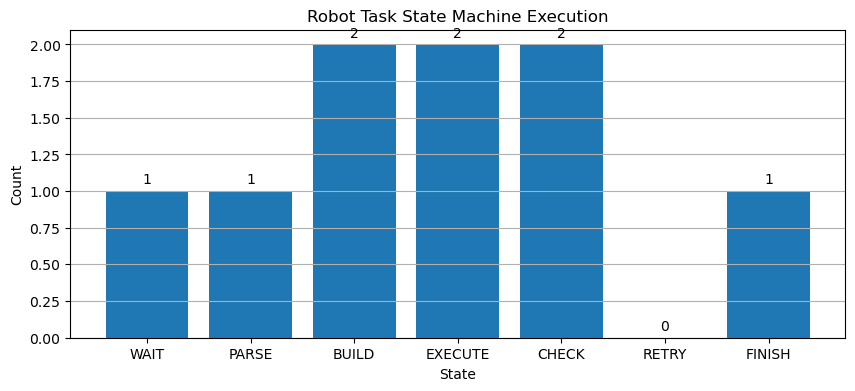

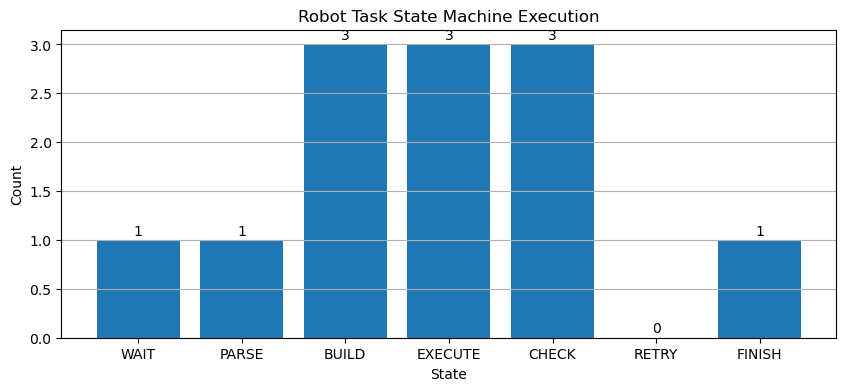

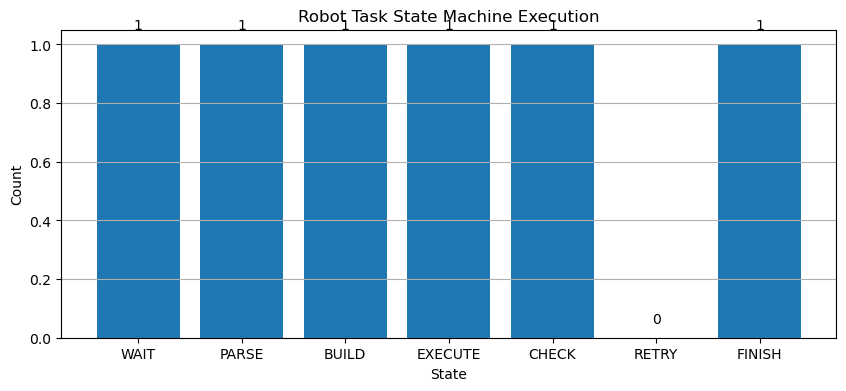

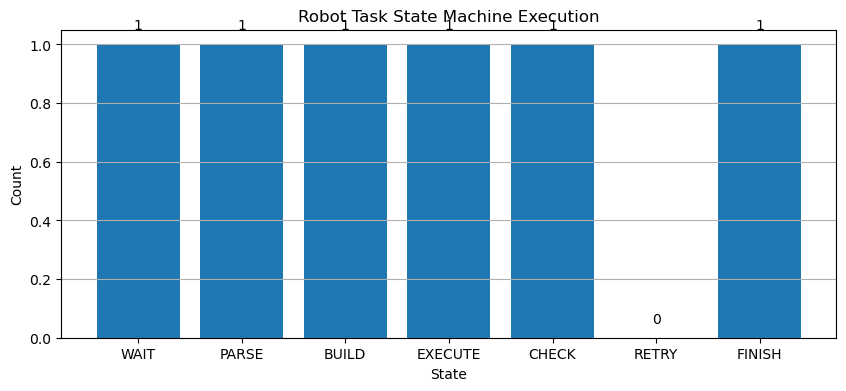

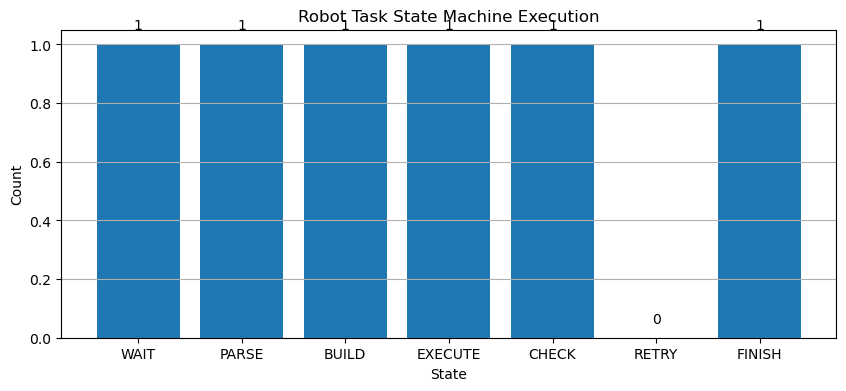

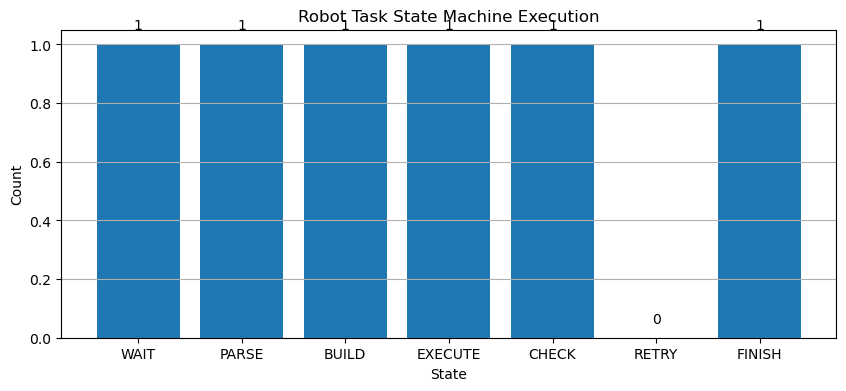

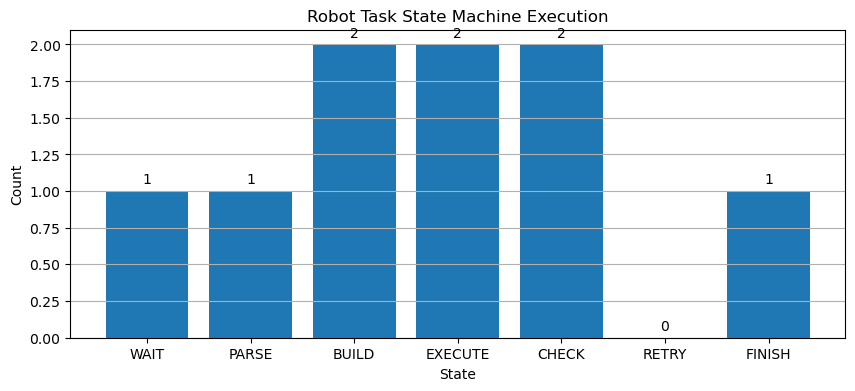

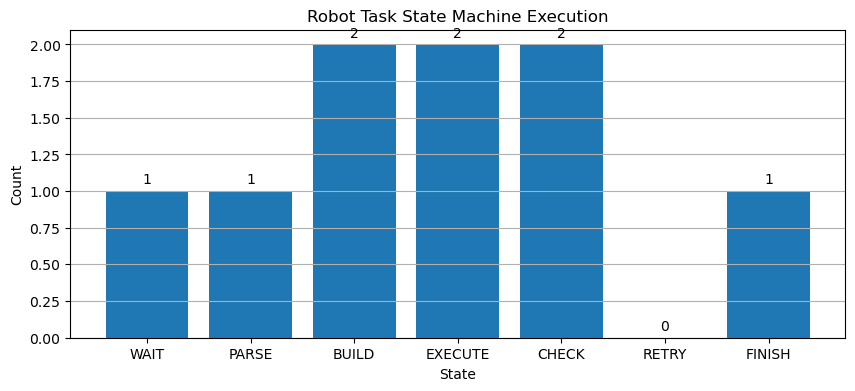

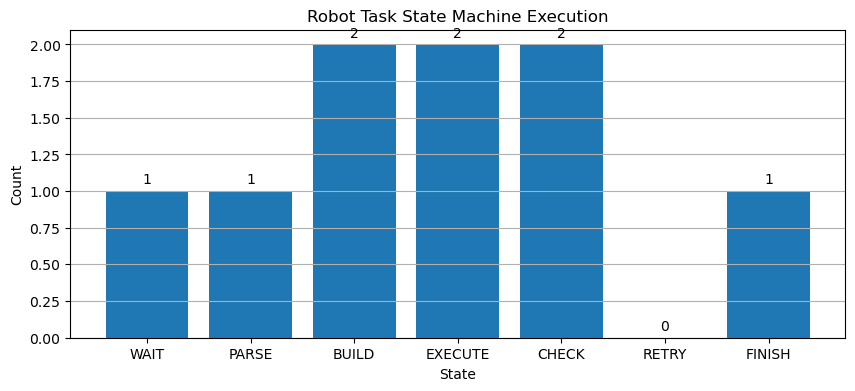

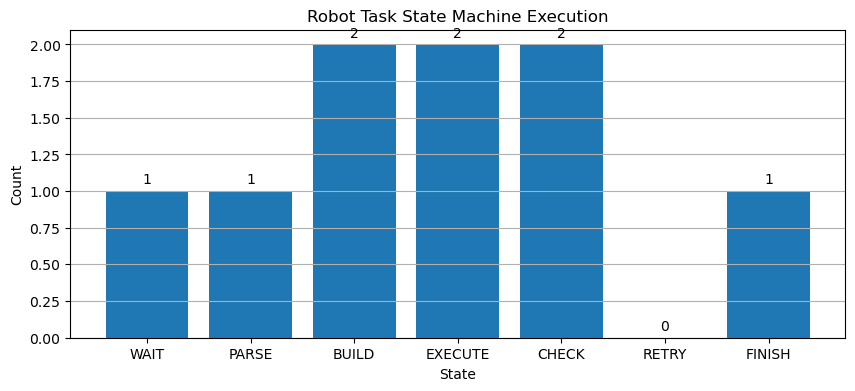

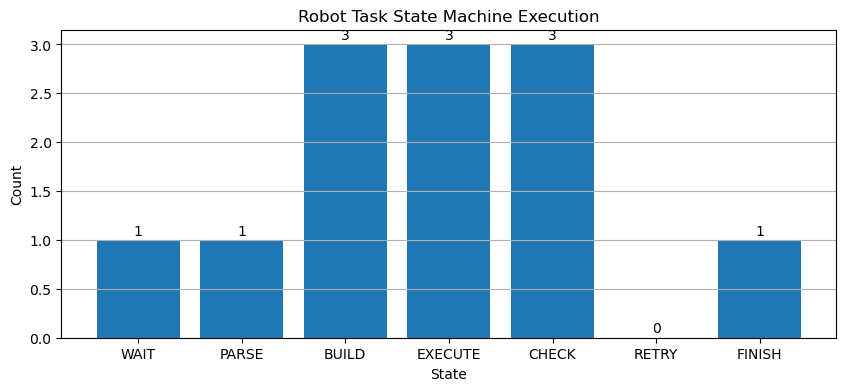

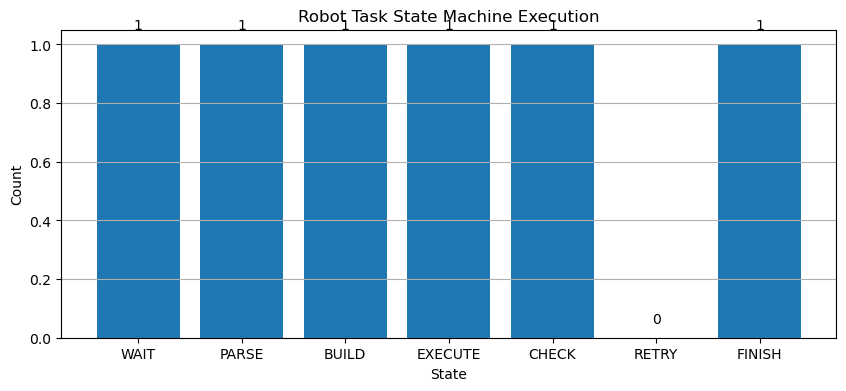

,场景,测试指令,解析成功,任务成功,任务数,重试次数,执行时间/s,错误原因
0,standard,把红色方块推到左边,True,True,1,0,0.0021,
1,standard,把绿色方块移动到中间,True,True,1,0,0.0018,
2,standard,把蓝色方块放到右侧,True,True,1,0,0.0016,
3,standard,先把红色方块推到左侧，然后返回起点,True,True,2,0,0.0040,
4,standard,先把蓝色方块送到右边，再把绿色方块移动到中央,True,True,2,0,0.0057,
5,standard,把红色方块推向左区，再把蓝色方块推向右区,True,True,2,0,0.0038,
6,standard,绿色方块移动到中部，最后回到起点,True,True,2,0,0.0022,
7,standard,先把红色方块放到左边，再把绿色方块放到中间，最后把蓝色方块放到右边,True,True,3,0,0.0088,
8,standard,把紫色方块推到左边,False,False,0,0,0.0000,第1步已识别颜色“紫色”，但当前场景中不存在对应颜色的方块
9,standard,把红色方块推到上面,False,False,0,0,0.0000,第1步包含不支持的目标区域：把红色方块推到上面


,场景,测试指令总数,正确解析数,指令解析成功率,合法指令执行成功率,平均重试次数,平均执行时间/s
0,standard,12,9,75.0%,100.0%,0.0,0.0035
1,swapped,12,9,75.0%,100.0%,0.0,0.0028
2,diagonal,12,9,75.0%,100.0%,0.0,0.0025
3,random,12,9,75.0%,100.0%,0.0,0.0038


In [23]:
TEST_COMMANDS = [
    "把红色方块推到左边",
    "把绿色方块移动到中间",
    "把蓝色方块放到右侧",
    "先把红色方块推到左侧，然后返回起点",
    "先把蓝色方块送到右边，再把绿色方块移动到中央",
    "把红色方块推向左区，再把蓝色方块推向右区",
    "绿色方块移动到中部，最后回到起点",
    "先把红色方块放到左边，再把绿色方块放到中间，最后把蓝色方块放到右边",
    "把紫色方块推到左边",      # 不支持的颜色
    "把红色方块推到上面",      # 不支持的区域
    "红色方块在左边",          # 缺少动作
    "返回起点",
]

TEST_SCENARIOS = [
    ("standard", None),
    ("swapped", None),
    ("diagonal", None),
    ("random", 7),
]

rows = []
for scenario, seed in TEST_SCENARIOS:
    for command in TEST_COMMANDS:
        if scenario == "random":
            build_scene(scenario, seed=seed)
        else:
            build_scene(scenario)
        outcome = execute_command(command, record=False)
        rows.append({
            "场景": scenario,
            "测试指令": command,
            "解析成功": outcome["parse_success"],
            "任务成功": outcome["task_success"],
            "任务数": len(outcome["tasks"]),
            "重试次数": sum(log["是否重试"] == "是" for log in outcome["logs"]),
            "执行时间/s": round(outcome["elapsed"], 4),
            "错误原因": "；".join(outcome["errors"]),
        })

results_df = pd.DataFrame(rows)
display(results_df)

summary_rows = []
for scenario, group in results_df.groupby("场景", sort=False):
    valid = group["解析成功"]
    summary_rows.append({
        "场景": scenario,
        "测试指令总数": len(group),
        "正确解析数": int(valid.sum()),
        "指令解析成功率": f"{valid.mean():.1%}",
        "合法指令执行成功率": f"{group.loc[valid, '任务成功'].mean():.1%}",
        "平均重试次数": round(group.loc[valid, "重试次数"].mean(), 3),
        "平均执行时间/s": round(group.loc[valid, "执行时间/s"].mean(), 4),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

results_df.to_csv(OUTPUT_DIR / "实验结果.csv", index=False, encoding="utf-8-sig")
summary_df.to_csv(OUTPUT_DIR / "实验汇总.csv", index=False, encoding="utf-8-sig")

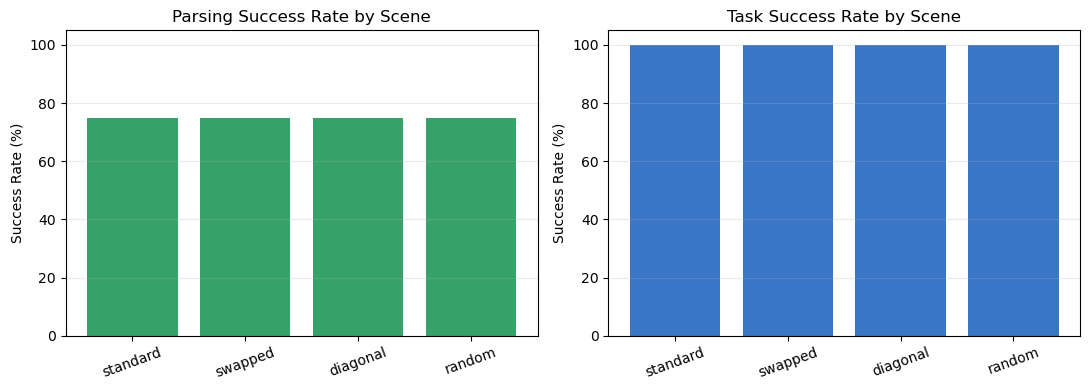

统计图已保存： topic3_outputs\实验统计图.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

scene_order = [item[0] for item in TEST_SCENARIOS]
parse_rates = []
task_rates = []
for scenario in scene_order:
    group = results_df[results_df["场景"] == scenario]
    parse_rates.append(group["解析成功"].mean() * 100)
    valid_group = group[group["解析成功"]]
    task_rates.append(valid_group["任务成功"].mean() * 100)

axes[0].bar(scene_order, parse_rates, color="#36a269")
axes[0].set_title("Parsing Success Rate by Scene")
axes[0].set_ylabel("Success Rate (%)")
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(scene_order, task_rates, color="#3976c5")
axes[1].set_title("Task Success Rate by Scene")
axes[1].set_ylabel("Success Rate (%)")
axes[1].set_ylim(0, 105)
axes[1].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
chart_path = OUTPUT_DIR / "实验统计图.png"
plt.savefig(chart_path, dpi=160, bbox_inches="tight")
plt.show()
print("统计图已保存：", chart_path)

## 7. 失败案例分析

### 案例一：未知颜色

输入“把紫色方块推到左边”。场景中没有紫色方块，因此系统拒绝执行，避免机器人寻找不存在的物体。

### 案例二：未知目标区域

输入“把红色方块推到上面”。本项目只定义左、中、右三个区域，因此系统提示目标区域无效。

### 案例三：首次执行未到达目标

完整演示中第一步故意只移动计划距离的55%。`check_success`检测到方块未进入目标区，系统调用`retry_skill`再次推动，并在日志中记录失败原因和重试结果。

这些案例说明，具身智能系统不仅要解析语言，还要检查环境状态和动作执行结果。

## 8. 项目结论

本项目建立了一个完整的“语言—任务—动作—反馈”闭环：

1. 规则解析器能处理三种颜色、三个目标区域、多种动作和多步骤指令；
2. 技能库把复杂任务拆成寻找、接近、推动、检查和返回等小动作；
3. 状态机按顺序执行任务，并记录每一步；
4. 失败检查和重试提高了系统可靠性；
5. PyBullet动画、日志和统计图让结果可观察、可评价。

### 小组分工

| 成员 | 工作 |
|---|---|
| 周雨琦 | PyBullet桌面、方块和机器人环境测试、日志、统计、视频 |
| 裘欣怡 | 中文规则解析器与同义词 |
| 张靖婕 | 机器人技能库 |
| 顾思言 | 状态机、成功检查与重试 |


## 9. 可继续改进的方向

1. 加入语音识别，让用户直接说出指令；
2. 使用虚拟相机识别方块，而不是直接读取仿真坐标；
3. 支持“离它最近的方块”等带有空间关系的指令；
4. 用大语言模型处理更灵活的表达，同时保留规则校验；
5. 将简化推杆换成带机械臂的抓取系统。